<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW1_Section_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laahir/MAT-422/blob/main/HW2/MAT422_HW1_Section_1_3.ipynb)

# MAT 422 - Homework 1 - Section 1.3: QR Decomposition, Least Squares, and Linear Regression

**Name:** Laahir
**Course:** MAT 422
**Topics covered:** QR decomposition, least-squares problems, linear regression

I'm using an example based on my job as a Math Instructional Aide, predicting a student's exam score from how many hours they studied and how many practice problems they did. This is a real overdetermined system, since I have more data points (students) than unknowns (coefficients), so it's a natural fit for least squares.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition

Any matrix A with independent columns can be written as A = Q R, where Q has orthonormal columns (same idea as Gram-Schmidt from the last homework) and R is upper triangular.

Here A holds data for 5 students: column 1 is all 1's (this will let us fit an intercept later), column 2 is hours studied, column 3 is number of practice problems completed.

In [9]:
# rows = students, columns = [intercept term, hours studied, practice problems done]
A = np.array([
    [1, 2, 5],
    [1, 4, 10],
    [1, 5, 8],
    [1, 7, 15],
    [1, 8, 12],
], dtype=float)

Q, R = np.linalg.qr(A)

print("A =")
print(A)
print("\nQ (orthonormal columns) =")
print(Q)
print("\nR (upper triangular) =")
print(R)

A =
[[ 1.  2.  5.]
 [ 1.  4. 10.]
 [ 1.  5.  8.]
 [ 1.  7. 15.]
 [ 1.  8. 12.]]

Q (orthonormal columns) =
[[-0.4472 -0.6702 -0.163 ]
 [-0.4472 -0.2513  0.4098]
 [-0.4472 -0.0419 -0.434 ]
 [-0.4472  0.377   0.6412]
 [-0.4472  0.5864 -0.4539]]

R (upper triangular) =
[[ -2.2361 -11.6276 -22.3607]
 [  0.       4.7749   6.4922]
 [  0.       0.       3.9813]]


In [10]:
# check 1: Q.T @ Q should be the identity matrix (columns are orthonormal)
identity_check = Q.T @ Q
print("Q.T @ Q =")
print(identity_check)
print("is it close to the identity matrix?", np.allclose(identity_check, np.eye(3)))

# check 2: Q @ R should reconstruct A exactly
reconstruction = Q @ R
print("\nQ @ R =")
print(reconstruction)
print("does Q @ R match the original A?", np.allclose(reconstruction, A))

Q.T @ Q =
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]
is it close to the identity matrix? True

Q @ R =
[[ 1.  2.  5.]
 [ 1.  4. 10.]
 [ 1.  5.  8.]
 [ 1.  7. 15.]
 [ 1.  8. 12.]]
does Q @ R match the original A? True


Both checks pass, so the decomposition is valid. Why bother with this instead of just working with A directly? Because A's columns can be close to redundant (hours studied and practice problems done tend to move together for students who are just generally more prepared), which makes some calculations numerically unstable. Q's columns are perfectly orthonormal by construction, so any computation that uses Q instead of A directly tends to be more stable and less sensitive to rounding error.

## 1.3.2 Least-Squares Problems

Now suppose I want to find coefficients beta such that 'A @ beta' approximates each student's actual exam score 'b', as closely as possible. Since I have 5 students (5 equations) but only 3 unknowns (3 coefficients), this system is overdetermined, there's usually no exact solution, only a best approximation.

Least squares finds the beta that minimizes the total squared error.

In [11]:
# actual exam scores (out of 100) for the same 5 students
b = np.array([68, 74, 78, 88, 85], dtype=float)

beta_hat, residuals_ss, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
print("least-squares coefficients (intercept, hours weight, problems weight) =", beta_hat)

predicted = A @ beta_hat
residual_vector = b - predicted
residual_norm = np.linalg.norm(residual_vector)

print("\npredicted scores =", predicted)
print("actual scores    =", b)
print("residual vector (actual - predicted) =", residual_vector)
print("residual norm ||b - A beta_hat|| =", residual_norm)

least-squares coefficients (intercept, hours weight, problems weight) = [59.2579  2.1616  0.8102]

predicted scores = [67.632  76.0061 76.5473 86.5418 86.2728]
actual scores    = [68. 74. 78. 88. 85.]
residual vector (actual - predicted) = [ 0.368  -2.0061  1.4527  1.4582 -1.2728]
residual norm ||b - A beta_hat|| = 3.16490159451017


In [12]:
# solve the same problem through QR instead of lstsq, and confirm we get the same answer
# for a full-rank A, the least squares solution satisfies R @ beta = Q.T @ b
beta_via_qr = np.linalg.solve(R, Q.T @ b)
print("beta via lstsq =", beta_hat)
print("beta via QR    =", beta_via_qr)
print("do they match?", np.allclose(beta_hat, beta_via_qr))

# normal-equation sanity check: A.T @ residual should be close to the zero vector
# this is the calculus condition for a minimum (the gradient of the error is zero)
normal_eq_check = A.T @ residual_vector
print("\nA.T @ residual =", normal_eq_check)
print("is it close to zero?", np.allclose(normal_eq_check, np.zeros(3)))

beta via lstsq = [59.2579  2.1616  0.8102]
beta via QR    = [59.2579  2.1616  0.8102]
do they match? True

A.T @ residual = [0. 0. 0.]
is it close to zero? True


Getting the same beta both ways is the real confirmation here. 'lstsq' solves the problem directly, while the QR route solves the smaller, cleaner triangular system `R @ beta = Q.T @ b`, which is exactly why QR decomposition matters for least squares in practice: it turns a harder problem into a system that's easy and numerically stable to solve with back-substitution.

## 1.3.3 Linear Regression

Now let's simplify to just one predictor, hours studied, and fit a plain line `score = beta_0 + beta_1 * hours`. This is the same least-squares idea, just with a smaller design matrix (a column of 1's for the intercept, plus the hours column).

In [13]:
hours = np.array([2, 4, 5, 7, 8, 3, 6], dtype=float)
scores = np.array([68, 74, 78, 88, 85, 70, 81], dtype=float)

X = np.column_stack([np.ones_like(hours), hours])
coeffs, _, _, _ = np.linalg.lstsq(X, scores, rcond=None)
intercept, slope = coeffs

print("intercept (beta_0) =", intercept)
print("slope (beta_1)     =", slope)

predicted_scores = X @ coeffs
residuals = scores - predicted_scores
rmse = np.sqrt(np.mean(residuals ** 2))
print("\npredicted scores =", predicted_scores)
print("RMSE (root mean squared error) =", rmse)

intercept (beta_0) = 60.9285714285714
slope (beta_1)     = 3.357142857142859

predicted scores = [67.6429 74.3571 77.7143 84.4286 87.7857 71.     81.0714]
RMSE (root mean squared error) = 1.767045268121854


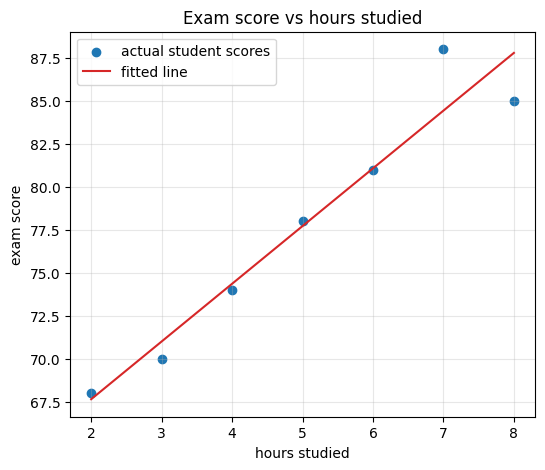

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(hours, scores, color="tab:blue", label="actual student scores")

hours_line = np.linspace(hours.min(), hours.max(), 50)
scores_line = intercept + slope * hours_line
plt.plot(hours_line, scores_line, color="tab:red", label="fitted line")

plt.xlabel("hours studied")
plt.ylabel("exam score")
plt.title("Exam score vs hours studied")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Interpreting this: the slope comes out to about 3.4, meaning each additional hour of studying is associated with roughly a 3.4-point increase in predicted exam score, on average, for this small sample. The intercept, about 61, is the model's predicted score at 0 hours studied, which is really just an extrapolation and shouldn't be taken too literally since nobody in the data actually studied 0 hours.

The RMSE comes out to about 1.8 points, meaning the line's predictions are typically off by less than 2 points from a student's actual score, which is a pretty tight fit for a small, real world style dataset like this.

## Reflection and Submission Checklist

- I explained each concept in my own words before showing the code.
- I checked my claims numerically instead of just trusting the math (`Q.T @ Q` close to identity, `Q @ R` reconstructing A, the QR-based and lstsq-based betas matching, the normal-equation residual near zero).
- I used a personal example (exam score prediction, tied to my job as a Math Instructional Aide) instead of a generic textbook dataset.
- I ran every cell top to bottom in Colab with no errors.
- I saved this notebook directly from Google Colab to GitHub so the Open in Colab badge works.